# <span style="color:darkblue"> Lecture 4b - Visualization  </span>

<font size = "5">

In this lecture we will focus on the standard "plt" usage and ...

- Export graphs to files
- Plot grouped statistics
- Change the style theme



# <span style="color:darkblue"> I. Setup working environment  </span>

<font size = "5">

Import libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

<font size = "5">

Import data

In [2]:
cars = pd.read_csv("data_raw/cars.csv")

# Source: "https://github.com/selva86/datasets/raw/master/mpg_ggplot2.csv"

In [3]:
cars

,Unnamed: 0,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
...,...,...,...,...,...,...,...,...,...,...,...,...
229,229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize
230,230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize
231,231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize
232,232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize


# <span style="color:darkblue"> II. Exporting and Organization </span>

<font size = "5">

Maintain an organized folder

- Differentiate raw/clean data, figures, results, etc...
- Essential for data quality
- Easier to handle big projects

$\qquad$ <img src="figures/folder_structure.png" alt="drawing" width="300"/>

<font size = "5">

Export to file

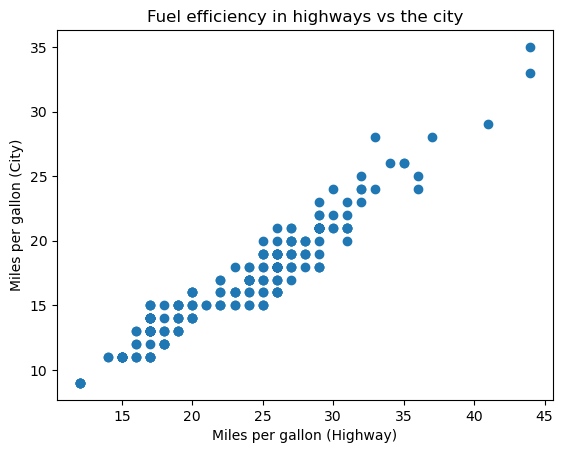

In [4]:
plt.scatter(x = cars["hwy"],y = cars["cty"])
plt.xlabel("Miles per gallon (Highway)")
plt.ylabel("Miles per gallon (City)")
plt.title("Fuel efficiency in highways vs the city")

# Store in different formas
plt.savefig("results/scatter_cty_hwy.png")
# plt.savefig("results/scatter_cty_hwy.jpg")

<font size = "5">

Pro Tips:

- **CHOOSE** self-explanatory names!
- **INCLUDE** time stamps or other systematic notation,
  <br> e.g. "2023-04-26-scatter_cars.png" <br>
- **AVOID** ambiguous notation like "scatter_cars_v4.png" 
- If working on a report, add figure numbers to file


<font size = "5">

Try it yourself!

- Store the above figure, with today's date <br>
in the file name as a "jpg" file
- Check that the file appears in your folder

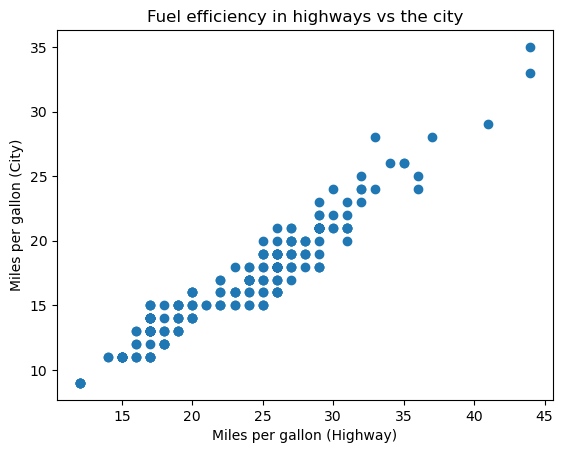

In [5]:
# Write your own code

plt.scatter(x = cars["hwy"],y = cars["cty"])
plt.xlabel("Miles per gallon (Highway)")
plt.ylabel("Miles per gallon (City)")
plt.title("Fuel efficiency in highways vs the city")

plt.savefig("results/2023-04-24-scatter.jpg")


# <span style="color:darkblue"> III. Plotting Grouped Data  </span>

<font size = "5">

Adding group indexing

In [6]:
# .groupby() adds a grouping index that can be used for grouped plotting
# ["..."] extracts a particular column from the dataset.
# Note: It's not always necessary to compute summary statistics after .groupby()

grouped_data = cars.groupby(['year'])["displ"]


In [7]:
grouped_data

<font size = "5">

Grouped statistics

In [8]:
# Compute frequency
grouped_counts_onelevel   = cars.groupby(['class']).size()
grouped_counts_multilevel = cars.groupby(['class','cyl']).size()

# Compute summary statistics by group
grouped_mean   = cars.groupby(['class','cyl'])["displ"].mean()
grouped_sum    = cars.groupby(['class','manufacturer'])["displ"].sum()
grouped_std    = cars.groupby(['class','manufacturer'])["displ"].std()
grouped_min    = cars.groupby(['class','manufacturer'])["displ"].min()
grouped_max    = cars.groupby(['class','manufacturer'])["displ"].max()

# Note: (1) Python will store the index in ".groupby()" for later plotting
#       (2) This is a succinct syntax for computing a single statistic.
#           More multiple statistics and/or custom names  use ".groupby().agg()"


In [10]:
grouped_sum

class       manufacturer
2seater     chevrolet       30.8
compact     audi            35.7
            nissan           4.8
            subaru          10.0
            toyota          27.5
            volkswagen      31.3
midsize     audi            10.1
            chevrolet       15.0
            hyundai         17.9
            nissan          21.5
            pontiac         19.8
            toyota          18.7
            volkswagen      16.8
minivan     dodge           37.3
pickup      dodge           89.9
            ford            33.0
            toyota          22.9
subcompact  ford            39.4
            honda           15.4
            hyundai         16.1
            subaru           9.4
            volkswagen      12.8
suv         chevrolet       50.4
            dodge           34.8
            ford            41.0
            jeep            36.6
            land rover      17.2
            lincoln         16.2
            mercury         17.6
            nissan

In [11]:
grouped_sum.unstack("class")

class,2seater,compact,midsize,minivan,pickup,subcompact,suv
manufacturer,,,,,,,
audi,NaN,35.7,10.1,NaN,NaN,NaN,NaN
chevrolet,30.8,NaN,15.0,NaN,NaN,NaN,50.4
dodge,NaN,NaN,NaN,37.3,89.9,NaN,34.8
ford,NaN,NaN,NaN,NaN,33.0,39.4,41.0
honda,NaN,NaN,NaN,NaN,NaN,15.4,NaN
hyundai,NaN,NaN,17.9,NaN,NaN,16.1,NaN
jeep,NaN,NaN,NaN,NaN,NaN,NaN,36.6
land rover,NaN,NaN,NaN,NaN,NaN,NaN,17.2
lincoln,NaN,NaN,NaN,NaN,NaN,NaN,16.2


<Axes: xlabel='manufacturer'>

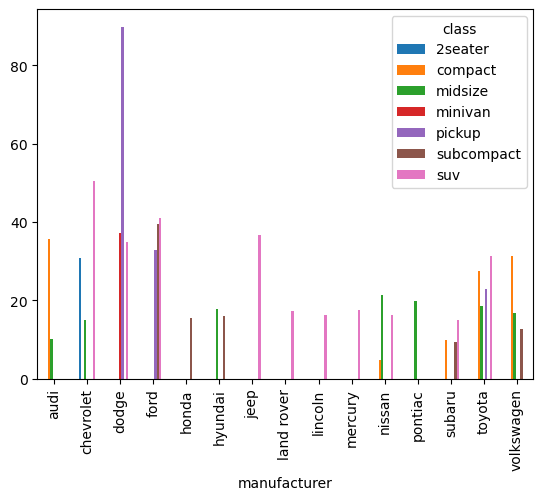

In [12]:
grouped_sum.unstack("class").plot(kind = "bar",stacked = False)

<Axes: xlabel='manufacturer'>

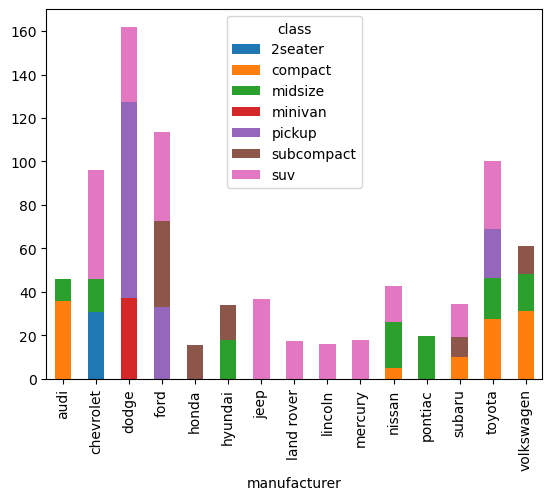

In [13]:
grouped_sum.unstack("class").plot(kind = "bar",stacked = True)

<font size = "5">

Histogram by groups

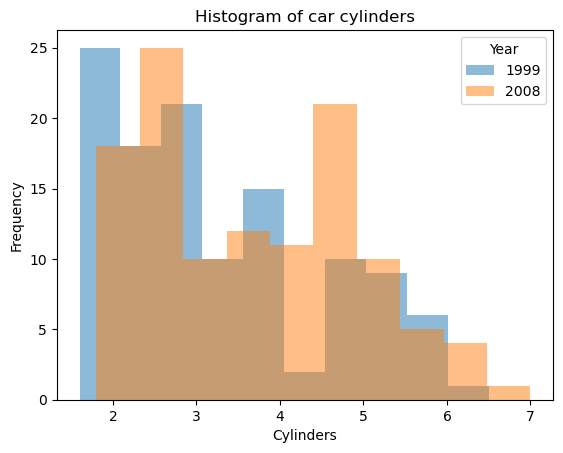

In [14]:
# To create overlapping histograms, use the "grouped_data" created above
# and the function ".plot.hist()" 
# The option "alpha" controls the transparency

grouped_data.plot.hist(alpha = 0.5)
plt.xlabel("Cylinders")
plt.ylabel("Frequency")
plt.title("Histogram of car cylinders")
plt.legend(title = "Year")



<font size = "5">

Bar chart

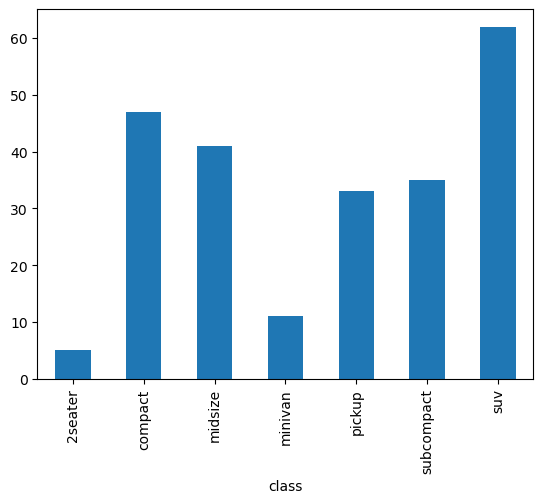

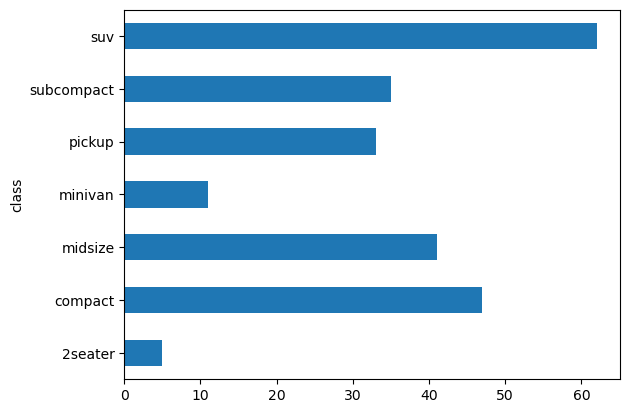

In [15]:
# A vertical bar plot
grouped_counts_onelevel.plot(kind = "bar")
plt.show()

# A horizontal bar plot
grouped_counts_onelevel.plot(kind = "barh")
plt.show()

# Note: (1) Other options in "kind" are "line"
#       (2) plt.show() is used to display the charts as separate plots

<font size = "5">

Multi-level bar chart

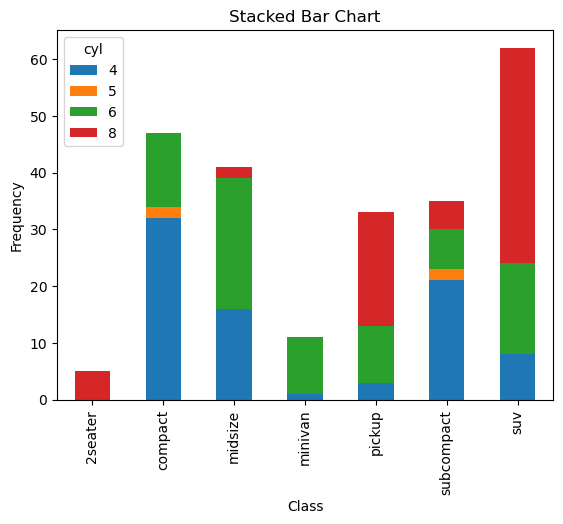

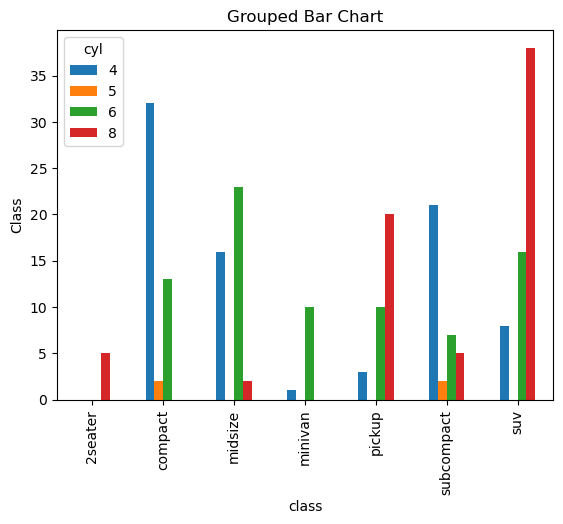

In [16]:
# .unstack("cyl") indicates that the plot should stack the results
# by "cyl" (cylinders).
grouped_counts_multilevel.unstack("cyl").plot(kind = "bar",stacked = True)
plt.title("Stacked Bar Chart")
plt.ylabel("Frequency")
plt.xlabel("Class")
plt.show()

# The grouped bar chart presents a histogram with two groupings, a primary
# and a secondary one. In this case "unstack("cyl")" indicates the secondary
# level
grouped_counts_multilevel.unstack("cyl").plot(kind = "bar",stacked = False)
plt.title("Grouped Bar Chart")
plt.ylabel("Frequency")
plt.ylabel("Class")
plt.show()

<font size = "5">

Legend options

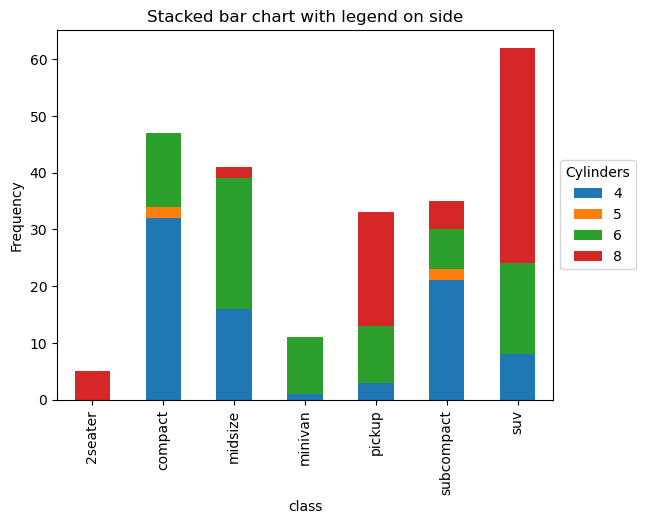

In [17]:
# Baseline plot
grouped_counts_multilevel.unstack("cyl").plot(kind = "bar",stacked = True)
plt.title("Stacked bar chart with legend on side")
plt.ylabel("Frequency")

# bbox_to_anchor(x,y) where (x,y) are the coordinates on the graph where values
#                     between 0 and 1. If the user specifies a value higher
#                     than one, it's put outside the graph.
# loc: The part of the legend where the point "bbox_to_anchor" is located
#      If "bbox_to_anchor" is not specified, this places the legend inside
#      the plot in the desired position.
# Best thing is to use different options to test the usage!

plt.legend(title='Cylinders',
           bbox_to_anchor=(1, 0.5),
           loc='center left',)


<font size = "5">

Try it yourself!

- Compute the standard deviation of "cty" grouped <br>
by "year" and "manufacturer"
- Display a grouped bar chart with "manufacturer" as the <br>
primary level and "year" as the secondary level
- Save the figure to <br>
"results/figure_barchart_stdcty_by_year.png"

In [ ]:
# Write your own code






# <span style="color:darkblue"> IV. Styles and further ideas for visualization </span>

<font size = "5" >

More plots!

https://www.machinelearningplus.com/plots/top-50-matplotlib-visualizations-the-master-plots-python/

<font size = "5">

Check available styles

In [ ]:
# Check which styles are available
plt.style.available


<font size = "5">

Set style

- ```plt.style.use()```
- Setting this command affects future plots in this file

Text(0.5, 1.0, 'Fuel efficiency in highways vs the city')

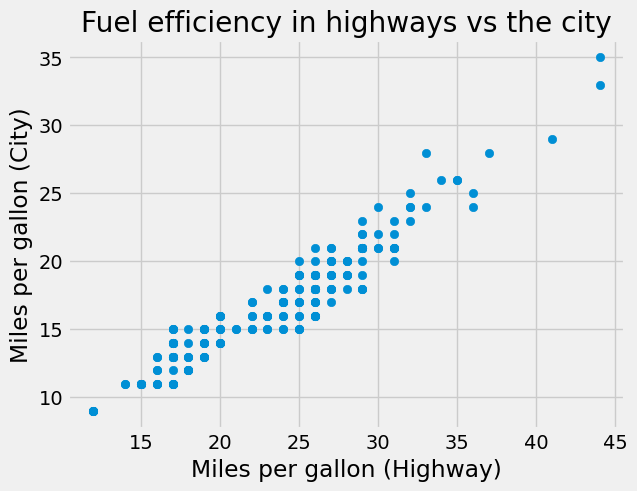

In [18]:
# Set the style. Can switch back by setting:    plt.style.use('default')

plt.style.use('fivethirtyeight')

plt.scatter(x = cars["hwy"],y = cars["cty"])
plt.xlabel("Miles per gallon (Highway)")
plt.ylabel("Miles per gallon (City)")
plt.title("Fuel efficiency in highways vs the city")


<font size = "5">

Try it yourself!

- Choose a style with ``` plt.style.use() ```
- Copy-paste the code for one of the plots above <br>
to see the new style

In [20]:
import seaborn

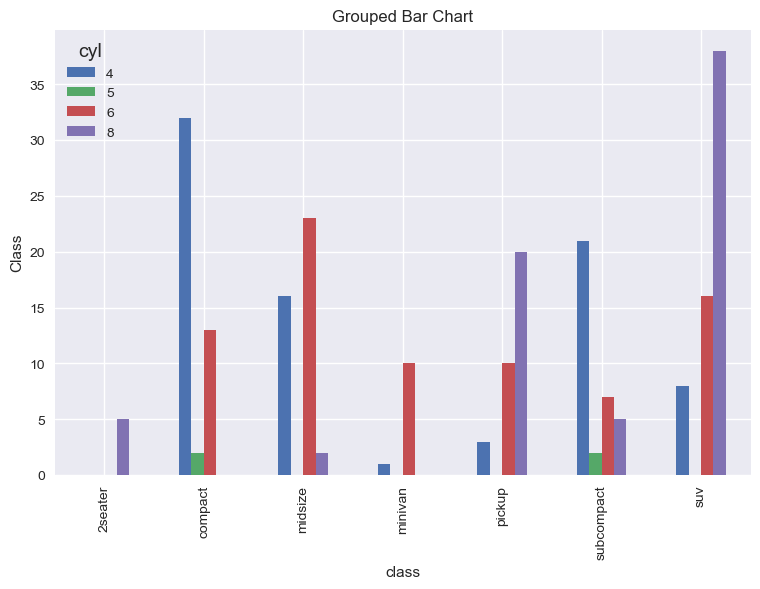

In [23]:
# Write your own code

# plt.style.use('seaborn-notebook') # this doesn't work
plt.style.use("seaborn-v0_8")

grouped_counts_multilevel.unstack("cyl").plot(kind = "bar",stacked = False)
plt.title("Grouped Bar Chart")
plt.ylabel("Frequency")
plt.ylabel("Class")
plt.show()
